# 🧪 Laboratorio 1 — Python para Inteligencia Artificial
## NumPy, pandas y scikit-learn

**Bootcamp IA Intermedio — Talento Tech Valle**  
**Sesión 1:** Sistemas de Inteligencia Artificial  

### Objetivos
- Familiarizarse con NumPy para cálculo numérico eficiente
- Manipular y analizar datos con pandas
- Realizar un Análisis Exploratorio de Datos (EDA)
- Construir un primer modelo de regresión lineal con scikit-learn

### Stack
- Python 3.10.12
- NumPy, pandas, matplotlib, scikit-learn

## 1. 🔢 Operaciones con NumPy

NumPy es la base del cálculo numérico en Python. Opera sobre 
arrays en memoria contigua (como C), lo que lo hace órdenes de 
magnitud más rápido que las listas nativas de Python.

En IA, todo modelo internamente es álgebra lineal: 
multiplicaciones de matrices, sumas, promedios. NumPy es el 
motor de eso.

### Ejemplo: array 3x3

In [5]:
import numpy as np

#creación de un array de 3x3 con valores aleatorios
array = np.random.rand(3,3)
print("Array original")
print(array)

#calculo de la suma de todos los elementos
total_sum = np.sum(array)
print(f"suma de todos los elementos: {total_sum}")

#calculo de la media de cada columna
column_mean = np.mean(array, axis=0)
print(f"Media de cada columna: {column_mean}")

Array original
[[0.63324246 0.16916697 0.33359705]
 [0.33513842 0.84527844 0.32184772]
 [0.72113398 0.61466737 0.98810309]]
suma de todos los elementos: 4.962175508334515
Media de cada columna: [0.56317162 0.5430376  0.54784929]


### 🎯 Reto: array 4x4 — máximo y mínimo por fila

`axis=1` opera sobre las filas (horizontal).  
`axis=0` opera sobre las columnas (vertical).

In [9]:
#cración de array de 4x4 con valores aleatorios
array2 = np.random.rand(4,4)
print("Array 4 x 4")
print(array2)

#maximo de cada fila
maximos = np.max(array2, axis=1)

#minimo de cada fila
minimos = np.min(array2, axis=1)

print(f"\nMaximo de cada fila: {maximos}")
print(f"\nMinimos de cada fila: {minimos}")

Array 4 x 4
[[0.6546237  0.01773944 0.19837501 0.55215119]
 [0.69498076 0.24650801 0.50853468 0.30494547]
 [0.57433583 0.51412487 0.34988966 0.1207225 ]
 [0.69628779 0.07154415 0.45026644 0.60634786]]

Maximo de cada fila: [0.6546237  0.69498076 0.57433583 0.69628779]

Minimos de cada fila: [0.01773944 0.24650801 0.1207225  0.07154415]


## 2. 🐼 Análisis de Datos con pandas

pandas introduce dos estructuras clave:
- **Series**: array unidimensional con índice (una columna)
- **DataFrame**: tabla bidimensional (como una tabla SQL en memoria)

Conectando con tu experiencia backend: un DataFrame es como 
el resultado de un `SELECT *` que puedes manipular en Python 
con sintaxis tipo query.

In [28]:
import pandas as pd

#suministrar los datos directamente como un diccionario

data = { 'Nombre': ['Juan', 'Ana', 'Luis', 'María', 'Pedro'],
         'Edad': [28, 34, 45, 23, 37], 
         'Ingresos_mensuales': [1500, 2000, 2500, 1800, 2200] }

#crear el DataFrame apartir del diccionario

df = pd.DataFrame(data)
print(f"Primeras 5 filas del DataFrame:")
print(df.head())

#Filtrar las filas donde la columna 'Edad' es mayor a 30
filtro = df[df['Edad'] > 30]
print("\nFilas donde la edad es mayor a 30")
print(filtro)

#Crear una nueva columna 'Ingresos anuales' a partir de 'Ingresos mensuales'
df['Ingresos_anuales'] = df['Ingresos_mensuales'] * 12
print("\nDataFrame con la nueva columna:")
print(df.head())

#filtar mayores de 25
mayores_25 = df[df["Edad"] > 25]
#Calcular promedio de ingresos anuales
promedio= mayores_25['Ingresos_anuales'].mean()

print("\nPromedio de ingresos anuales de personas mayores de 25:")
print(promedio)

Primeras 5 filas del DataFrame:
  Nombre  Edad  Ingresos_mensuales
0   Juan    28                1500
1    Ana    34                2000
2   Luis    45                2500
3  María    23                1800
4  Pedro    37                2200

Filas donde la edad es mayor a 30
  Nombre  Edad  Ingresos_mensuales
1    Ana    34                2000
2   Luis    45                2500
4  Pedro    37                2200

DataFrame con la nueva columna:
  Nombre  Edad  Ingresos_mensuales  Ingresos_anuales
0   Juan    28                1500             18000
1    Ana    34                2000             24000
2   Luis    45                2500             30000
3  María    23                1800             21600
4  Pedro    37                2200             26400

Promedio de ingresos anuales de personas mayores de 25:
24600.0


## 3. 📊 Análisis Exploratorio de Datos (EDA)

El EDA es el paso previo obligatorio antes de entrenar cualquier 
modelo. Responde preguntas como:
- ¿Hay valores nulos?
- ¿Cómo se distribuyen los datos?
- ¿Hay outliers?

`df.describe()` entrega en una sola línea: count, mean, std, 
min, percentiles 25/50/75 y max de cada columna numérica.

Estadísticas descriptivas:
            Edad  Ingresos_mensuales  Ingresos_anuales
count   5.000000            5.000000          5.000000
mean   33.400000         2000.000000      24000.000000
std     8.443933          380.788655       4569.463864
min    23.000000         1500.000000      18000.000000
25%    28.000000         1800.000000      21600.000000
50%    34.000000         2000.000000      24000.000000
75%    37.000000         2200.000000      26400.000000
max    45.000000         2500.000000      30000.000000


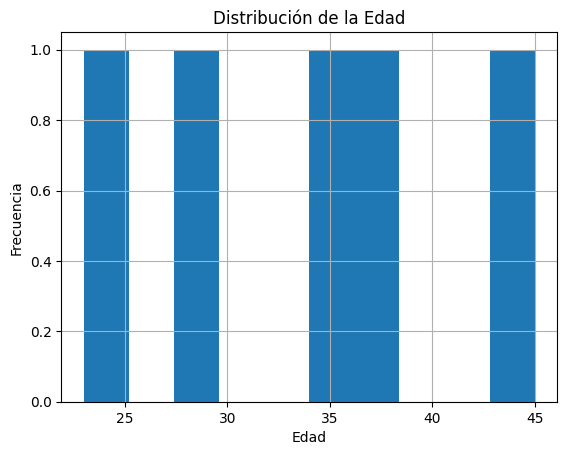

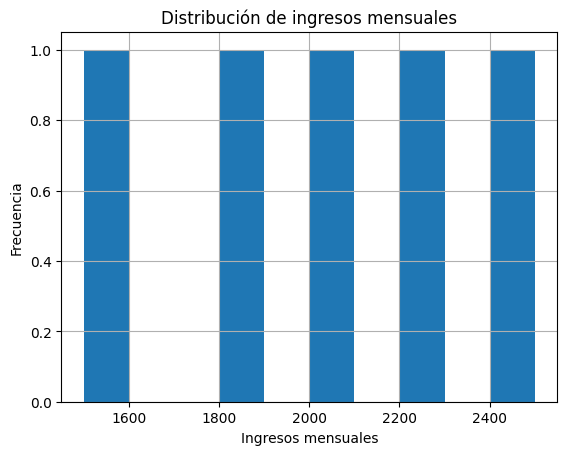

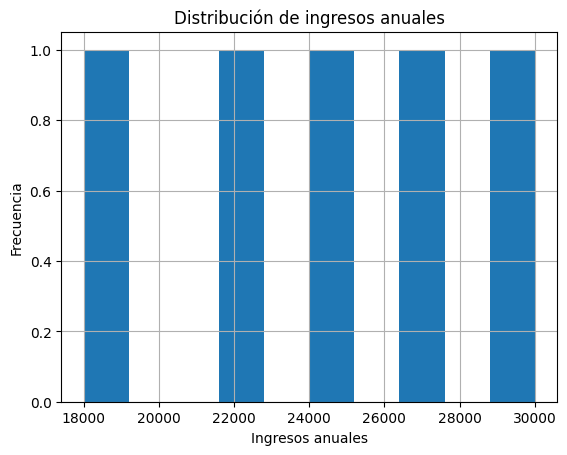

In [36]:
# Mostrar estadísticas descriptivas del DataFrame 
print("Estadísticas descriptivas:") 
print(df.describe())
# Visualizar la distribución de una columna con un histograma 
import matplotlib.pyplot as plt
df['Edad'].hist(bins=10)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Edad') 
plt.show()

df['Ingresos_mensuales'].hist(bins=10)
plt.xlabel('Ingresos mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de ingresos mensuales') 
plt.show()

df['Ingresos_anuales'].hist(bins=10)
plt.xlabel('Ingresos anuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de ingresos anuales') 
plt.show()



## 4. 🤖 Introducción a scikit-learn — Regresión Lineal

La regresión lineal busca la recta `y = mx + b` que minimiza 
el error entre predicciones y valores reales.

**Variables:**
- `X` (feature): Ingresos mensuales
- `y` (target): Edad

**Métricas de evaluación:**
- **MSE** (Mean Squared Error): promedio de los errores al 
  cuadrado. Cuanto más bajo, mejor.
- **R²** (R-squared): qué proporción de la varianza de `y` 
  explica el modelo. Rango [-∞, 1]. Ideal: cerca de 1.

> ⚠️ **Nota importante:** Este dataset tiene solo 5 registros.  
> Con `test_size=0.3` el conjunto de prueba tiene apenas 1-2 
> muestras, lo que hace que las métricas no sean estadísticamente 
> confiables. En la práctica se necesitan cientos o miles de 
> registros para evaluar un modelo correctamente.  
> Este ejercicio es ilustrativo del flujo de trabajo, no del 
> resultado.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#definir variables predictoras y objetivo
x = df[['Ingresos_mensuales']]
y = df['Edad']

#dividir los datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#crear el modelo de regresión lineal y entrenanrlo
modelo = LinearRegression()
modelo.fit(x_train, y_train)

#realizar predicciones y calucular el error cuadrático medio
y_pred = modelo.predict(x_test)


# evaluar modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio:", mse)
print("R² score:", r2)
print(len(y_test))
print("Datos totales:", len(df))
print("Datos test:", len(y_test))
print("Valores test:", y_test)
print("Predicciones:", y_pred)


Error cuadrático medio: 0.2655023233456164
R² score: 0.8819989674019483
2
Datos totales: 5
Datos test: 2
Valores test: 1    34
4    37
Name: Edad, dtype: int64
Predicciones: [33.30379747 37.21518987]


## 📝 Conclusiones

1. **NumPy** es el motor matemático de bajo nivel. Operar con 
   arrays es esencial para entender cómo los modelos procesan 
   datos internamente.

2. **pandas** permite cargar, limpiar y transformar datos antes 
   de pasarlos a un modelo. Un buen preprocesamiento define el 
   techo de calidad de cualquier modelo.

3. **El EDA** no es opcional. Visualizar distribuciones y 
   estadísticas descriptivas evita entrenar modelos sobre datos 
   mal entendidos.

4. **scikit-learn** abstrae la complejidad matemática de los 
   algoritmos. El flujo siempre es: `split → fit → predict → 
   evaluate`.

5. El **tamaño del dataset importa**. Con 5 filas no se puede 
   concluir nada sobre el modelo, pero el flujo de trabajo es 
   exactamente el mismo que con millones de registros.